# DICOM Data Analysis Pipeline — Portfolio Demo

**Author:** Anmol Wadhwa
**Purpose:** Demonstrate an end-to-end DICOM data-handling pipeline covering the stages a hospital / imaging-centre IT team cares about: ingestion, metadata extraction, quality/compliance validation, de-identification (PHI handling), pixel-data visualization, basic image processing, and aggregate analytics/reporting.

> **Note on data:** No real patient data is used anywhere in this notebook. We use the small, public, synthetic DICOM sample files that ship inside the `pydicom` library (CT, MR, ultrasound, RT, secondary capture, etc.), which is why this notebook runs standalone in Colab with no downloads, credentials, or PHI exposure. The same code paths work unmodified against a real PACS export or a DICOMweb (QIDO-RS/WADO-RS) pull — see the **Production Considerations** section at the end for how this would plug into a real archive.

## Pipeline stages
1. Setup & environment
2. Ingestion — walk a folder of `.dcm` files, parse headers safely
3. Metadata inventory — structured DataFrame of key tags
4. Data quality & DICOM-conformance checks
5. De-identification (PHI scrubbing, PS3.15-style)
6. Pixel data decoding & windowed visualization
7. Basic image processing (normalization, contrast enhancement)
8. Aggregate analytics dashboard
9. Export & reporting artifacts
10. Production considerations for a real imaging-centre deployment


## 1. Setup & Environment

In [1]:
# Core libraries for DICOM parsing, data wrangling, imaging, and plotting.
!pip install -q pydicom pandas numpy matplotlib scikit-image



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import io
import glob
import json
import shutil
import hashlib
import zipfile
from datetime import datetime, timezone
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydicom
from pydicom.data import get_testdata_files
from pydicom.errors import InvalidDicomError

# A handful of pydicom's bundled sample files are deliberately malformed
# edge cases (truncated pixel data, non-standard VRs) used to exercise
# pydicom's own test suite. Our pipeline catches and reports these
# conditions explicitly (see the QC section), so we quiet the underlying
# library warnings here to keep this demo's output readable.
warnings.filterwarnings("ignore", category=UserWarning, module="pydicom")

print("pydicom version:", pydicom.__version__)
print("pandas version:", pd.__version__)


pydicom version: 3.0.2
pandas version: 3.0.6


## 2. Ingestion

In production this step would point at an inbound C-STORE landing directory, a DICOMweb WADO-RS export, or a batch of files pulled from a PACS query (QIDO-RS). Here we simulate an "incoming study" folder by copying pydicom's bundled sample datasets — which span multiple modalities (CT, MR, US, secondary capture, RT structure sets) — into a working directory, exactly as an ingestion job would see files land on disk.

In [3]:
WORKDIR = Path("/content/dicom_pipeline_demo")
INBOX = WORKDIR / "inbox"
INBOX.mkdir(parents=True, exist_ok=True)

sample_paths = [p for p in get_testdata_files("*.dcm")]
print(f"Found {len(sample_paths)} sample DICOM files bundled with pydicom.")

for src in sample_paths:
    dst = INBOX / Path(src).name
    if not dst.exists():
        shutil.copy(src, dst)

inbox_files = sorted(glob.glob(str(INBOX / "*.dcm")))
print(f"Staged {len(inbox_files)} files in inbox: {INBOX}")


Found 157 sample DICOM files bundled with pydicom.
Staged 157 files in inbox: \content\dicom_pipeline_demo\inbox


In [4]:
def safe_read_dicom(path):
    """Read a DICOM file, tolerating files without a valid preamble/meta header."""
    try:
        return pydicom.dcmread(path, force=False), None
    except InvalidDicomError:
        try:
            # Some vendor exports omit the 128-byte preamble; force=True still
            # requires the caller to treat the result with caution.
            return pydicom.dcmread(path, force=True), "no_preamble_forced_read"
        except Exception as e:
            return None, f"unreadable: {e}"
    except Exception as e:
        return None, f"unreadable: {e}"

read_results = {}
for f in inbox_files:
    ds, warning = safe_read_dicom(f)
    read_results[f] = (ds, warning)

n_ok = sum(1 for ds, _ in read_results.values() if ds is not None)
n_fail = len(read_results) - n_ok
print(f"Successfully parsed: {n_ok} | Failed to parse: {n_fail}")


Successfully parsed: 157 | Failed to parse: 0

## 3. Metadata Inventory

Pull the tags a PACS/RIS integration or a data-quality dashboard would want: patient/study/series identifiers, modality, acquisition parameters, image geometry, and transfer syntax. Missing tags are recorded as `None` rather than raising, since real-world archives are never 100% complete.

In [5]:
def tag(ds, keyword, default=None):
    return getattr(ds, keyword, default)

def build_inventory_row(path, ds, warning):
    if ds is None:
        return {"filepath": path, "parse_error": warning}

    row = {
        "filepath": path,
        "parse_error": warning,
        "PatientID": tag(ds, "PatientID"),
        "PatientName": str(tag(ds, "PatientName")) if tag(ds, "PatientName") else None,
        "PatientBirthDate": tag(ds, "PatientBirthDate"),
        "PatientSex": tag(ds, "PatientSex"),
        "StudyInstanceUID": tag(ds, "StudyInstanceUID"),
        "SeriesInstanceUID": tag(ds, "SeriesInstanceUID"),
        "SOPInstanceUID": tag(ds, "SOPInstanceUID"),
        "StudyDate": tag(ds, "StudyDate"),
        "StudyDescription": tag(ds, "StudyDescription"),
        "SeriesDescription": tag(ds, "SeriesDescription"),
        "Modality": tag(ds, "Modality"),
        "Manufacturer": tag(ds, "Manufacturer"),
        "ManufacturerModelName": tag(ds, "ManufacturerModelName"),
        "InstitutionName": tag(ds, "InstitutionName"),
        "Rows": tag(ds, "Rows"),
        "Columns": tag(ds, "Columns"),
        "BitsAllocated": tag(ds, "BitsAllocated"),
        "PixelSpacing": str(tag(ds, "PixelSpacing")) if tag(ds, "PixelSpacing") else None,
        "SliceThickness": tag(ds, "SliceThickness"),
        "TransferSyntaxUID": (
            str(getattr(ds.file_meta, "TransferSyntaxUID", None))
            if getattr(ds, "file_meta", None) is not None and getattr(ds.file_meta, "TransferSyntaxUID", None) is not None
            else None
        ),
        "HasPixelData": "PixelData" in ds,
        "FileSizeKB": round(os.path.getsize(path) / 1024, 1),
    }
    return row

rows = [build_inventory_row(f, ds, warning) for f, (ds, warning) in read_results.items()]
inventory_df = pd.DataFrame(rows)
inventory_df.head(10)


,filepath,parse_error,PatientID,PatientName,PatientBirthDate,PatientSex,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID,StudyDate,...,ManufacturerModelName,InstitutionName,Rows,Columns,BitsAllocated,PixelSpacing,SliceThickness,TransferSyntaxUID,HasPixelData,FileSizeKB
0,\content\dicom_pipeline_demo\inbox\693_J2KI.dcm,NaN,CQ500-CT-310,CQ500-CT-310,,,1.2.276.0.7230010.3.1.2.296485376.1.1521713414...,1.2.276.0.7230010.3.1.3.296485376.1.1521713419...,1.2.826.0.1.3680043.2.1143.6234428899086018376...,,...,,NaN,512.0,512.0,16.0,"[0.478516, 0.478516]",5.0,1.2.840.10008.1.2.4.91,True,3.5
1,\content\dicom_pipeline_demo\inbox\693_J2KR.dcm,NaN,CQ500-CT-310,CQ500-CT-310,,,1.2.276.0.7230010.3.1.2.296485376.1.1521713414...,1.2.276.0.7230010.3.1.3.296485376.1.1521713419...,1.2.276.0.7230010.3.1.4.296485376.1.1521713419...,,...,,NaN,512.0,512.0,16.0,"[0.478516, 0.478516]",5.0,1.2.840.10008.1.2.4.90,True,104.6
2,\content\dicom_pipeline_demo\inbox\693_UNCI.dcm,NaN,CQ500-CT-310,CQ500-CT-310,,,1.2.276.0.7230010.3.1.2.296485376.1.1521713414...,1.2.276.0.7230010.3.1.3.296485376.1.1521713419...,1.2.826.0.1.3680043.2.1143.6234428899086018376...,,...,,NaN,512.0,512.0,16.0,"[0.478516, 0.478516]",5.0,1.2.840.10008.1.2.1,True,514.0
3,\content\dicom_pipeline_demo\inbox\693_UNCR.dcm,NaN,CQ500-CT-310,CQ500-CT-310,,,1.2.276.0.7230010.3.1.2.296485376.1.1521713414...,1.2.276.0.7230010.3.1.3.296485376.1.1521713419...,1.2.276.0.7230010.3.1.4.296485376.1.1521713419...,,...,,NaN,512.0,512.0,16.0,"[0.478516, 0.478516]",5.0,1.2.840.10008.1.2.1,True,513.7
4,\content\dicom_pipeline_demo\inbox\CT_small.dcm,NaN,1CT1,CompressedSamples^CT1,,O,1.3.6.1.4.1.5962.1.2.1.20040119072730.12322,1.3.6.1.4.1.5962.1.3.1.1.20040119072730.12322,1.3.6.1.4.1.5962.1.1.1.1.1.20040119072730.12322,20040119,...,RHAPSODE,JFK IMAGING CENTER,128.0,128.0,16.0,"[0.661468, 0.661468]",5.0,1.2.840.10008.1.2.1,True,38.3
5,\content\dicom_pipeline_demo\inbox\ExplVR_BigE...,NaN,NaN,Anonymized,NaN,NaN,1.2.840.113619.2.21.848.246800003.0.1952805748.3,1.2.840.113619.2.21.24680000.700.0.1952805748.3.0,1.2.840.1136190195280574824680000700.3.0.1.199...,1997.04.24,...,LOGIQ 700,GE MEDICAL SYSTEMS,60.0,80.0,8.0,NaN,NaN,1.2.840.10008.1.2.2,True,15.1
6,\content\dicom_pipeline_demo\inbox\ExplVR_BigE...,no_preamble_forced_read,NaN,NaN,NaN,NaN,1.2.333.4444.5.6.7.8.9,1.2.333.4444.5.6.7.8.99,1.2.333.4444.5.6.7.8,20150515,...,XiO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.4
7,\content\dicom_pipeline_demo\inbox\ExplVR_LitE...,no_preamble_forced_read,NaN,NaN,NaN,NaN,1.2.333.4444.5.6.7.8.9,1.2.333.4444.5.6.7.8.99,1.2.333.4444.5.6.7.8,20150515,...,XiO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.4
8,\content\dicom_pipeline_demo\inbox\GDCMJ2K_Tex...,NaN,NaN,NaN,NaN,NaN,1.3.6.1.4.35045.178713654550621507378357964392...,1.3.6.1.4.35045.144617642844613360096093938825...,1.3.6.1.4.35045.258255395321547846922642016970...,20110617,...,NaN,NaN,400.0,400.0,8.0,NaN,NaN,1.2.840.10008.1.2.4.90,True,30.0
9,\content\dicom_pipeline_demo\inbox\HTJ2KLossle...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.2.826.0.1.3680043.8.498.32503923131738778902...,NaN,...,NaN,NaN,480.0,640.0,8.0,NaN,NaN,1.2.840.10008.1.2.4.201,True,384.0


In [6]:
print("Inventory shape:", inventory_df.shape)
inventory_df.dtypes


Inventory shape: (157, 24)


filepath                     str
parse_error                  str
PatientID                    str
PatientName                  str
PatientBirthDate             str
PatientSex                   str
StudyInstanceUID             str
SeriesInstanceUID            str
SOPInstanceUID               str
StudyDate                    str
StudyDescription             str
SeriesDescription            str
Modality                     str
Manufacturer                 str
ManufacturerModelName        str
InstitutionName              str
Rows                     float64
Columns                  float64
BitsAllocated            float64
PixelSpacing                 str
SliceThickness           float64
TransferSyntaxUID            str
HasPixelData                bool
FileSizeKB               float64
dtype: object

In [7]:
INVENTORY_CSV = WORKDIR / "dicom_inventory.csv"
inventory_df.to_csv(INVENTORY_CSV, index=False)
print("Saved metadata inventory to", INVENTORY_CSV)


Saved metadata inventory to \content\dicom_pipeline_demo\dicom_inventory.csv


## 4. Data Quality & DICOM-Conformance Checks

A real intake pipeline needs automated gatekeeping before files are routed into the PACS: are required tags present, is pixel data decodable, is the transfer syntax one the viewer/archive supports? Below is a lightweight rules engine producing a per-file QC report — the kind of thing that would normally feed an alerting dashboard or quarantine queue.

In [8]:
REQUIRED_TAGS = [
    "PatientID", "StudyInstanceUID", "SeriesInstanceUID", "SOPInstanceUID", "Modality",
]

SUPPORTED_TRANSFER_SYNTAXES = {
    "1.2.840.10008.1.2",       # Implicit VR Little Endian
    "1.2.840.10008.1.2.1",     # Explicit VR Little Endian
    "1.2.840.10008.1.2.4.50",  # JPEG Baseline
    "1.2.840.10008.1.2.4.70",  # JPEG Lossless
    "1.2.840.10008.1.2.4.90",  # JPEG 2000 Lossless
    "1.2.840.10008.1.2.4.91",  # JPEG 2000
}

def qc_check(path, ds, warning):
    issues = []

    if ds is None:
        return {"filepath": path, "issues": [warning or "unreadable"], "issue_count": 1, "status": "FAIL"}

    if warning:
        issues.append(warning)

    for req in REQUIRED_TAGS:
        if not getattr(ds, req, None):
            issues.append(f"missing_required_tag:{req}")

    ts_raw = getattr(ds.file_meta, "TransferSyntaxUID", None) if getattr(ds, "file_meta", None) else None
    if ts_raw is None:
        issues.append("missing_transfer_syntax")
    elif str(ts_raw) not in SUPPORTED_TRANSFER_SYNTAXES:
        issues.append(f"unsupported_transfer_syntax:{ts_raw}")

    if "PixelData" in ds:
        try:
            _ = ds.pixel_array
        except Exception as e:
            issues.append(f"pixel_data_decode_error:{type(e).__name__}")
    else:
        # Expected for non-image SOP classes (structured reports, RT structure
        # sets, key object selections) -- absence alone isn't a defect.
        issues.append("no_pixel_data")

    # Only genuinely broken instances (unparseable, missing identifiers, or
    # pixel data present but corrupt) are treated as hard failures. Everything
    # else -- e.g. a non-image object with no pixel data, or a transfer syntax
    # this basic pipeline doesn't decode -- is a WARN worth a human glance,
    # not a rejection.
    HARD_FAIL_PREFIXES = ("unreadable", "missing_required_tag", "pixel_data_decode_error")
    if not issues:
        status = "PASS"
    elif any(i.startswith(HARD_FAIL_PREFIXES) for i in issues):
        status = "FAIL"
    else:
        status = "WARN"
    return {"filepath": path, "issues": issues, "issue_count": len(issues), "status": status}

qc_rows = [qc_check(f, ds, warning) for f, (ds, warning) in read_results.items()]
qc_df = pd.DataFrame(qc_rows)
qc_df["issues_str"] = qc_df["issues"].apply(lambda x: "; ".join(x) if x else "")
qc_df[["filepath", "status", "issue_count", "issues_str"]].sort_values("issue_count", ascending=False).head(15)


,filepath,status,issue_count,issues_str
14,\content\dicom_pipeline_demo\inbox\JLSL_RGB_IL...,FAIL,8,no_preamble_forced_read; missing_required_tag:...
17,\content\dicom_pipeline_demo\inbox\JLSN_RGB_IL...,FAIL,8,no_preamble_forced_read; missing_required_tag:...
16,\content\dicom_pipeline_demo\inbox\JLSL_RGB_IL...,FAIL,8,no_preamble_forced_read; missing_required_tag:...
15,\content\dicom_pipeline_demo\inbox\JLSL_RGB_IL...,FAIL,8,no_preamble_forced_read; missing_required_tag:...
138,\content\dicom_pipeline_demo\inbox\no_meta.dcm,FAIL,8,no_preamble_forced_read; missing_required_tag:...
135,\content\dicom_pipeline_demo\inbox\meta_missin...,FAIL,7,missing_required_tag:PatientID; missing_requir...
23,\content\dicom_pipeline_demo\inbox\JPEGLSNearL...,FAIL,6,missing_required_tag:PatientID; missing_requir...
12,\content\dicom_pipeline_demo\inbox\JLSL_08_07_...,FAIL,6,missing_required_tag:PatientID; missing_requir...
13,\content\dicom_pipeline_demo\inbox\JLSL_16_15_...,FAIL,6,missing_required_tag:PatientID; missing_requir...
9,\content\dicom_pipeline_demo\inbox\HTJ2KLossle...,FAIL,6,missing_required_tag:PatientID; missing_requir...


status
PASS    73
FAIL    51
WARN    33
Name: count, dtype: int64


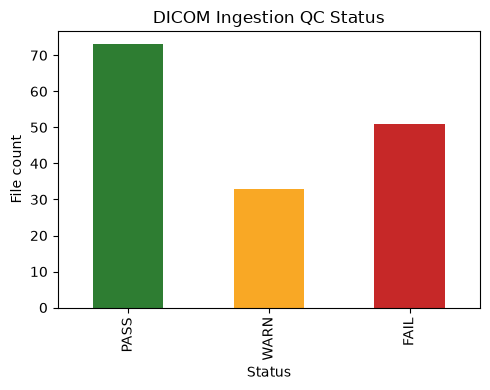

In [9]:
status_counts = qc_df["status"].value_counts()
print(status_counts)

fig, ax = plt.subplots(figsize=(5, 4))
status_counts.reindex(["PASS", "WARN", "FAIL"]).fillna(0).plot(
    kind="bar", ax=ax, color=["#2e7d32", "#f9a825", "#c62828"]
)
ax.set_title("DICOM Ingestion QC Status")
ax.set_ylabel("File count")
ax.set_xlabel("Status")
plt.tight_layout()
plt.show()


In [10]:
QC_CSV = WORKDIR / "dicom_qc_report.csv"
qc_df.drop(columns=["issues"]).to_csv(QC_CSV, index=False)
print("Saved QC report to", QC_CSV)


Saved QC report to \content\dicom_pipeline_demo\dicom_qc_report.csv


## 5. De-identification (PHI Handling)

Any pipeline that touches imaging data an IT department will actually trust needs to show it takes PHI seriously. Below is a simplified de-identification routine loosely modelled on the **DICOM PS3.15 Basic Application Level Confidentiality Profile**: direct identifiers are blanked or consistently pseudonymized, private/vendor tags are stripped, and the file is flagged as de-identified per the standard.

**This is a demonstration, not a certified de-identification tool.** A production deployment should use a validated product (e.g. RSNA CTP, Orthanc's anonymization plugin, or the `dicom-anonymizer` library) and have its tag list reviewed against the institution's own PHI policy and Safe Harbor / Expert Determination requirements.

In [11]:
SALT = b"demo-salt-change-me-per-deployment"  # in production: pull from a secrets manager

def pseudonymize(value: str) -> str:
    """Deterministic pseudonym: same input always maps to same output, without reversibility."""
    digest = hashlib.sha256(SALT + str(value).encode("utf-8")).hexdigest()[:12]
    return f"ANON-{digest}"

PHI_TAGS_TO_PSEUDONYMIZE = ["PatientID"]
PHI_TAGS_TO_BLANK = [
    "PatientName", "PatientBirthDate", "PatientAddress", "OtherPatientIDs",
    "OtherPatientNames", "InstitutionName", "InstitutionAddress",
    "ReferringPhysicianName", "PerformingPhysicianName", "OperatorsName",
    "StationName", "RequestingPhysician", "PhysiciansOfRecord",
]

def deidentify(ds):
    ds = ds.copy()

    for t in PHI_TAGS_TO_PSEUDONYMIZE:
        if hasattr(ds, t):
            setattr(ds, t, pseudonymize(getattr(ds, t)))

    for t in PHI_TAGS_TO_BLANK:
        if hasattr(ds, t):
            setattr(ds, t, "")

    # Strip vendor/private tags, which can carry embedded PHI (e.g. burned-in overlays).
    ds.remove_private_tags()

    # Flag per DICOM PS3.15 so downstream systems know this instance was processed.
    ds.PatientIdentityRemoved = "YES"
    ds.DeidentificationMethod = "Demo pipeline: basic tag blanking + pseudonymized PatientID"

    return ds

# Demonstrate on the first readable file with pixel data
demo_path, (demo_ds, _) = next((f, r) for f, r in read_results.items() if r[0] is not None)
before = {t: getattr(demo_ds, t, None) for t in ["PatientID", "PatientName", "InstitutionName"]}
deid_ds = deidentify(demo_ds)
after = {t: getattr(deid_ds, t, None) for t in ["PatientID", "PatientName", "InstitutionName"]}

print("Before:", before)
print("After: ", after)


Before: {'PatientID': 'CQ500-CT-310', 'PatientName': 'CQ500-CT-310', 'InstitutionName': None}
After:  {'PatientID': 'ANON-e49ffc34846c', 'PatientName': '', 'InstitutionName': None}


In [12]:
DEID_DIR = WORKDIR / "deidentified"
DEID_DIR.mkdir(exist_ok=True)

deid_count, deid_failures = 0, []
for f, (ds, warning) in read_results.items():
    if ds is None:
        continue
    deid = deidentify(ds)
    out_path = DEID_DIR / Path(f).name
    try:
        # write_like_original=True preserves the source file's own meta-header
        # encoding; a handful of edge-case files in this sample set have an
        # incomplete file_meta and would otherwise fail strict re-validation.
        deid.save_as(out_path, write_like_original=True)
        deid_count += 1
    except Exception as e:
        deid_failures.append((Path(f).name, str(e)))

print(f"De-identified {deid_count} files -> {DEID_DIR}")
if deid_failures:
    print(f"Skipped {len(deid_failures)} files with incomplete/non-conformant file meta:")
    for name, err in deid_failures:
        print(f"  - {name}: {err}")


De-identified 157 files -> \content\dicom_pipeline_demo\deidentified


## 6. Pixel Data Decoding & Windowed Visualization

Not every sample is a raw image (some are RT structure sets or reports with no pixel data). We filter to instances that carry pixel data, apply rescale slope/intercept where present, and use `WindowCenter`/`WindowWidth` for CT-style windowing when available — the same logic a viewer uses to render diagnostically-appropriate contrast.

In [13]:
from pydicom.pixels import apply_color_lut

COLOR_PHOTOMETRIC_INTERPRETATIONS = {
    "RGB", "YBR_FULL", "YBR_FULL_422", "YBR_RCT", "YBR_ICT", "PALETTE COLOR",
}

def get_display_array(ds):
    """Return (array, is_color) ready for imshow, handling both grayscale
    (windowed) and color ultrasound/photo modalities correctly."""
    arr = ds.pixel_array
    photometric = getattr(ds, "PhotometricInterpretation", "MONOCHROME2")

    if arr.ndim >= 3 and arr.shape[0] > 1 and photometric not in ("RGB",):
        arr = arr[0]  # multi-frame: show the first frame

    if photometric in COLOR_PHOTOMETRIC_INTERPRETATIONS:
        if photometric == "PALETTE COLOR":
            arr = apply_color_lut(arr, ds)
        arr = arr.astype(np.float64)
        lo, hi = arr.min(), arr.max()
        arr = (arr - lo) / (hi - lo) if hi > lo else np.zeros_like(arr)
        return arr, True

    arr = arr.astype(np.float64)
    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    arr = arr * slope + intercept

    wc = getattr(ds, "WindowCenter", None)
    ww = getattr(ds, "WindowWidth", None)
    if wc is not None and ww is not None:
        wc = float(wc[0] if isinstance(wc, pydicom.multival.MultiValue) else wc)
        ww = float(ww[0] if isinstance(ww, pydicom.multival.MultiValue) else ww)
        lo, hi = wc - ww / 2, wc + ww / 2
    else:
        lo, hi = np.percentile(arr, [1, 99])

    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo) if hi > lo else np.zeros_like(arr)

    # MONOCHROME1 encodes 0 = white / max = black -- the opposite of the usual
    # radiological display convention -- so invert it to render correctly.
    if photometric == "MONOCHROME1":
        arr = 1.0 - arr

    return arr, False

viewable = []
for f, (ds, warning) in read_results.items():
    if ds is not None and "PixelData" in ds:
        try:
            _ = ds.pixel_array
            viewable.append((f, ds))
        except Exception:
            continue

print(f"{len(viewable)} instances have decodable pixel data out of {len(read_results)} total.")


113 instances have decodable pixel data out of 157 total.


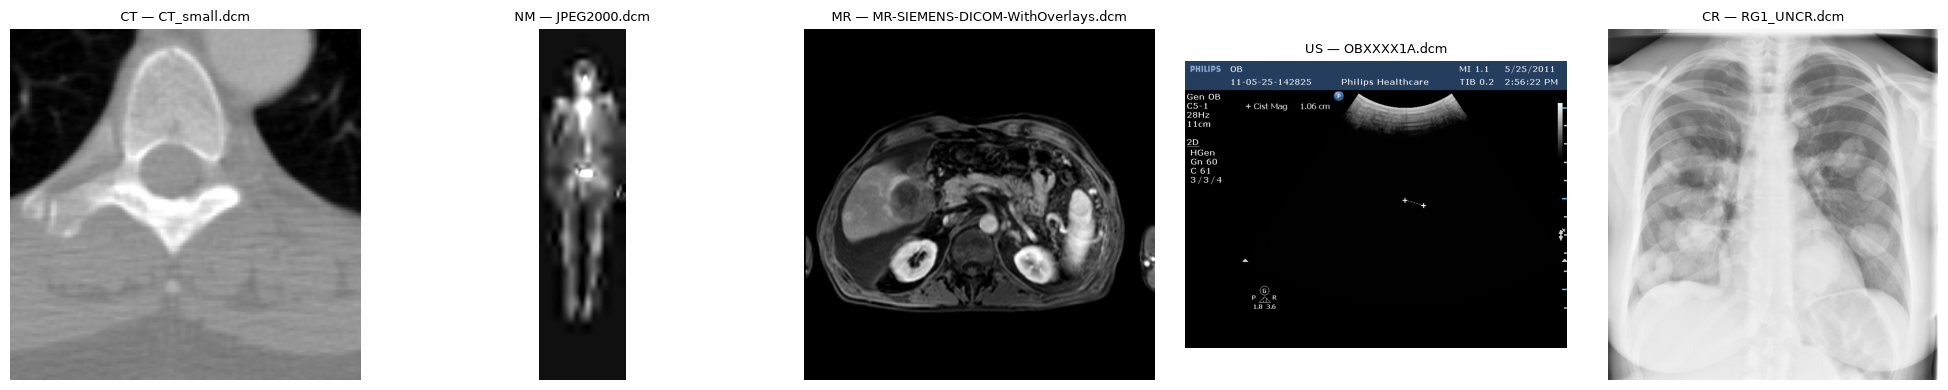

In [14]:
# Curate one clean, reasonably-sized instance per modality for the gallery,
# rather than whatever happens to sort first -- some bundled fixtures are
# tiny thumbnails or deliberately-corrupted decoder stress tests.
PREFERRED_FILENAMES = {
    "CT": "CT_small.dcm",
    "MR": "MR-SIEMENS-DICOM-WithOverlays.dcm",
    "US": "OBXXXX1A.dcm",
    "CR": "RG1_UNCR.dcm",
}

CLINICAL_MODALITIES = {"CT", "MR", "US", "CR", "DX", "MG", "NM", "PT", "XA", "RF"}

by_modality = {}
for f, ds in viewable:
    rows, cols = getattr(ds, "Rows", 0) or 0, getattr(ds, "Columns", 0) or 0
    modality = getattr(ds, "Modality", None)
    if modality not in CLINICAL_MODALITIES or rows < 128 or cols < 128:
        continue
    is_preferred = Path(f).name == PREFERRED_FILENAMES.get(modality)
    if modality not in by_modality or is_preferred:
        by_modality[modality] = (f, ds)

gallery = list(by_modality.values())[:6]

fig, axes = plt.subplots(1, len(gallery), figsize=(4 * len(gallery), 4))
if len(gallery) == 1:
    axes = [axes]

for ax, (f, ds) in zip(axes, gallery):
    try:
        img, is_color = get_display_array(ds)
        ax.imshow(img, cmap=None if is_color else "gray")
    except Exception as e:
        ax.text(0.5, 0.5, f"decode error:\n{e}", ha="center", va="center", wrap=True)
    ax.set_title(f"{getattr(ds, 'Modality', '?')} — {Path(f).name}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 7. Basic Image Processing

A quick demonstration of two common pre-processing steps used before feeding images to a viewer, a QA tool, or a downstream ML model: min-max normalization and contrast-limited adaptive histogram equalization (CLAHE).

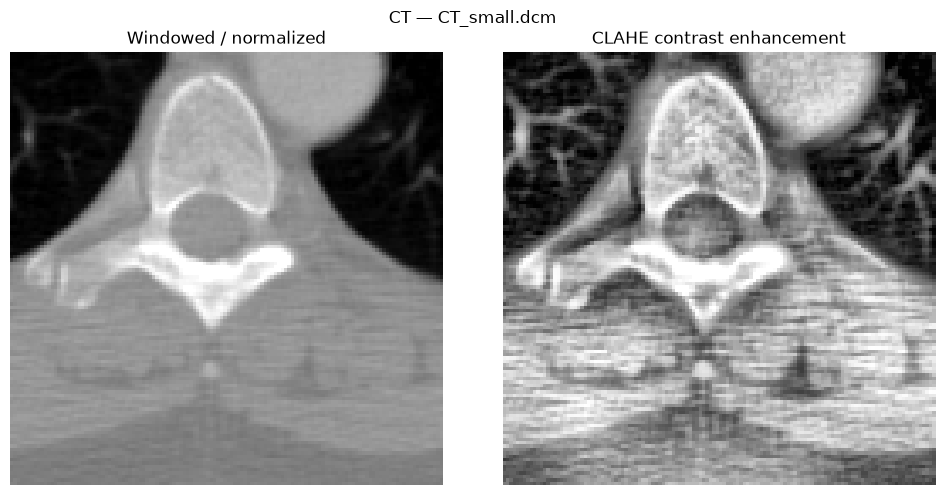

In [15]:
from skimage import exposure

# Pick a clean grayscale instance (CLAHE operates on single-channel images).
sample_f, sample_ds = next(
    (f, ds) for f, ds in gallery
    if getattr(ds, "PhotometricInterpretation", "") not in COLOR_PHOTOMETRIC_INTERPRETATIONS
)
raw, _ = get_display_array(sample_ds)

clahe_img = exposure.equalize_adapthist(raw, clip_limit=0.02)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(raw, cmap="gray")
axes[0].set_title("Windowed / normalized")
axes[0].axis("off")

axes[1].imshow(clahe_img, cmap="gray")
axes[1].set_title("CLAHE contrast enhancement")
axes[1].axis("off")

plt.suptitle(f"{getattr(sample_ds, 'Modality', '?')} — {Path(sample_f).name}")
plt.tight_layout()
plt.show()


## 8. Aggregate Analytics Dashboard

The kind of summary view an imaging-centre IT/operations team would want on a rolling basis: modality mix, equipment/vendor mix, and image size distribution across the ingested batch.

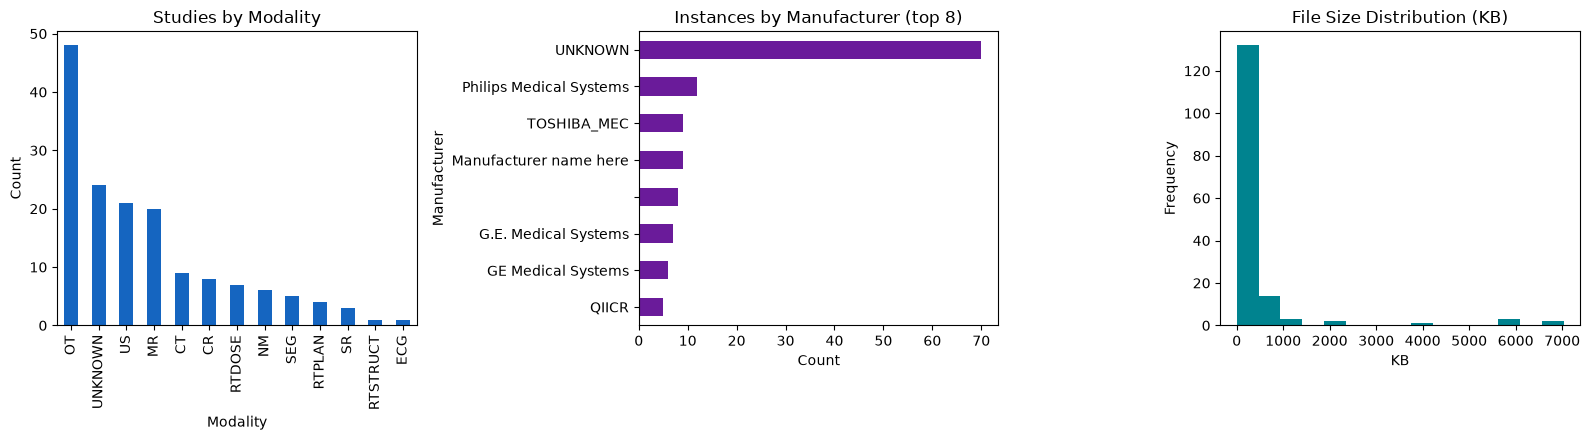

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

inventory_df["Modality"].fillna("UNKNOWN").value_counts().plot(
    kind="bar", ax=axes[0], color="#1565c0"
)
axes[0].set_title("Studies by Modality")
axes[0].set_ylabel("Count")

top_manufacturers = inventory_df["Manufacturer"].fillna("UNKNOWN").value_counts().head(8)
top_manufacturers.plot(kind="barh", ax=axes[1], color="#6a1b9a")
axes[1].set_title("Instances by Manufacturer (top 8)")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

inventory_df["FileSizeKB"].plot(
    kind="hist", bins=15, ax=axes[2], color="#00838f"
)
axes[2].set_title("File Size Distribution (KB)")
axes[2].set_xlabel("KB")

plt.tight_layout()
plt.show()


In [17]:
summary = {
    "total_files_ingested": len(inventory_df),
    "unique_patients": inventory_df["PatientID"].nunique(dropna=True),
    "unique_studies": inventory_df["StudyInstanceUID"].nunique(dropna=True),
    "modalities_seen": sorted(inventory_df["Modality"].dropna().unique().tolist()),
    "qc_pass": int((qc_df["status"] == "PASS").sum()),
    "qc_warn": int((qc_df["status"] == "WARN").sum()),
    "qc_fail": int((qc_df["status"] == "FAIL").sum()),
    "total_size_mb": round(inventory_df["FileSizeKB"].sum() / 1024, 2),
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}
summary


{'total_files_ingested': 157,
 'unique_patients': 25,
 'unique_studies': 37,
 'modalities_seen': ['CR',
  'CT',
  'ECG',
  'MR',
  'NM',
  'OT',
  'RTDOSE',
  'RTPLAN',
  'RTSTRUCT',
  'SEG',
  'SR',
  'US'],
 'qc_pass': 73,
 'qc_warn': 33,
 'qc_fail': 51,
 'total_size_mb': np.float64(58.8),
 'generated_at_utc': '2026-09-23T05:50:31.221286+00:00'}

## 9. Export & Reporting Artifacts

In [18]:
REPORT_PATH = WORKDIR / "pipeline_summary_report.json"
with open(REPORT_PATH, "w") as fh:
    json.dump(summary, fh, indent=2)

ZIP_PATH = WORKDIR / "deidentified_dataset.zip"
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in DEID_DIR.glob("*.dcm"):
        zf.write(p, arcname=p.name)

print("Artifacts written:")
for p in [INVENTORY_CSV, QC_CSV, REPORT_PATH, ZIP_PATH]:
    print(" -", p, f"({os.path.getsize(p)/1024:.1f} KB)")


Artifacts written:
 - \content\dicom_pipeline_demo\dicom_inventory.csv (49.3 KB)
 - \content\dicom_pipeline_demo\dicom_qc_report.csv (17.7 KB)
 - \content\dicom_pipeline_demo\pipeline_summary_report.json (0.4 KB)
 - \content\dicom_pipeline_demo\deidentified_dataset.zip (35324.0 KB)


In [19]:
# In Colab, uncomment to download the artifacts locally:
# from google.colab import files
# files.download(str(INVENTORY_CSV))
# files.download(str(QC_CSV))
# files.download(str(REPORT_PATH))
# files.download(str(ZIP_PATH))


## 10. Production Considerations for a Real Imaging-Centre Deployment

This notebook demonstrates the pipeline logic end-to-end on safe sample data. Talking points for how it maps onto a real environment:

- **Ingestion at scale:** replace the folder walk with a DICOM C-STORE SCP (e.g. `pynetdicom`) or DICOMweb STOW-RS receiver; process asynchronously via a queue (e.g. Celery/RabbitMQ or cloud pub/sub) rather than in-process.
- **PACS/VNA integration:** query existing studies via QIDO-RS / C-FIND, retrieve via WADO-RS / C-MOVE. Orthanc is a good open-source reference PACS for building and testing this against.
- **De-identification compliance:** swap the demo `deidentify()` for a validated tool (RSNA CTP, Orthanc anonymization plugin, or `dicom-anonymizer`), have the tag list reviewed by compliance/legal against HIPAA Safe Harbor or the institution's own policy, and audit-log every de-identification event.
- **Data quality at scale:** run the QC engine as a pre-commit gate before instances are archived; route FAIL status into a quarantine bucket with alerting (email/Slack/ticket) rather than silently dropping files.
- **Storage & security:** encrypt at rest and in transit, apply role-based access control, and keep de-identified research copies physically/logically separated from the clinical PACS.
- **Throughput:** parallelize metadata extraction and pixel decoding with multiprocessing or a distributed framework (Spark/Dask) once volumes exceed a single-machine workload.
- **Observability:** feed the aggregate analytics (modality mix, QC pass rate, throughput, storage growth) into a persistent dashboard (Grafana/Metabase) rather than regenerating plots ad hoc.
- **Downstream ML/analytics:** the normalized/windowed arrays produced in Section 6-7 are the same preprocessing a triage or CAD model would expect as input, making this pipeline a natural front door for an ML-assisted workflow.
